# C4 — Sample complexity & rare attacks (bản revision)

**Bài**: TETC-2026-05-0252 · **Phần**: C4 (Quan) + chuyển giao UNSW-NB15

Notebook này **không train lại gì cả**. Nó nạp artifact đã sinh, kiểm chứng lại, dựng bảng
và vẽ hình. Chạy hết mất khoảng một phút.

---

## Vì sao C4 không phải một notebook train

C1/C2/C3 mỗi cái chạy một lần trên một cấu hình nên notebook là hợp lý. C4 phải quét

$$2\ \text{dataset} \times 2\ \text{chế độ lấy mẫu} \times 2\ \text{chế độ biểu diễn}
\times 2\ \text{arm} \times 7\ N \times 10\ \text{run} \times 7\ \text{model}$$

Nhét vào notebook thì không đặt được cache theo ô, không chạy lại được riêng một ô hỏng, và
mỗi lần treo máy là mất hết. Nên phần chạy nằm ở module + CLI:

| Đường dẫn | Vai trò |
|---|---|
| `src/c4_pipeline.py` | Logic: lấy mẫu lồng nhau, biểu diễn, kernel, tuning, thống kê, gate |
| `runners/run_c4.py` | Chạy thí nghiệm — `--dataset --regime --repr-mode --arms --n-grid --run-ids` |
| `runners/analyze_c4.py` | Learning curve, thống kê ghép cặp, rare-attack, crossover |
| `runners/pairwise_all_arms.py` | Bảng thống kê phủ hết arm/split |
| `runners/audit_c4.py` | Soát lỗi độc lập (§2 bên dưới) |
| `runners/make_paper1_figures.py` | Sinh 4 hình cho bản revision |
| `configs/c4_protocol.json` | Protocol đóng băng + `_changelog` |

**Chạy lại toàn bộ thí nghiệm** (nhiều giờ, không cần cho notebook này):

```bash
python runners/run_c4.py --dataset nslkdd --regime natural  --arms tuned_per_N frozen_c2
python runners/run_c4.py --dataset nslkdd --regime matched  --arms tuned_per_N frozen_c2
python runners/run_c4.py --dataset unsw   --regime natural  --arms tuned_per_N tuned_once
python runners/analyze_c4.py --dataset nslkdd --regime natural
python runners/pairwise_all_arms.py
```

In [1]:
from pathlib import Path
import sys, json, subprocess

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "configs" / "c4_protocol.json").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("khong tim thay goc repo")
    ROOT = ROOT.parent
sys.path[:0] = [str(ROOT), str(ROOT / "src"), str(ROOT / "runners")]

%matplotlib inline
import make_paper1_figures as figs

pd.set_option("display.width", 160, "display.max_columns", 40)
NSL = ROOT / "results/nslkdd/c4_revision"
UNSW = ROOT / "results/unsw/c4_revision"
print("goc repo:", ROOT)

goc repo: D:\QSVM_NSLKDD


## 1. Protocol và artifact

Protocol được **đóng băng trước khi chạy** và mọi thay đổi sau đó đều ghi vào `_changelog`.

In [2]:
proto = json.loads((ROOT / "configs/c4_protocol.json").read_text(encoding="utf-8"))

print("Nhung lua chon da dong bang")
print("  run            :", proto["sampling"]["n_runs"], "run, seed",
      proto["sampling"]["run_seeds"][:3], "...")
print("  phan tang      :", proto["sampling"]["stratify_by"]["definition"])
for regime, cfg in proto["sampling"]["regimes"].items():
    print(f"  N ({regime:8s}):", cfg["n_grid"])
print("  UNSW           :", proto["dataset_overrides"]["unsw"]["n_qubits"], "qubit, K =",
      proto["dataset_overrides"]["unsw"]["select_k"])
print("\n_changelog:", len(proto.get("_changelog", [])), "muc")
for e in proto.get("_changelog", []):
    print("  -", (e.get("change") or e.get("note") or str(e))[:110])

Nhung lua chon da dong bang
  run            : 10 run, seed [100, 101, 102] ...
  phan tang      : {Normal, DoS, Probe, R2L_union_U2R}
  N (matched ): [100, 200, 500, 1000, 2000]
  N (natural ): [100, 200, 500, 1000, 2000, 5000, 10000, 20000]
  UNSW           : 6 qubit, K = 35

_changelog: 8 muc
  - sampling.stratify_by: doi tu 'attack_category' (5 lop) sang nhan 4 lop {Normal, DoS, Probe, R2L_union_U2R}
  - n_grid mo rong tu [100..5000] len [100..10000]; them kernel_computation.method = statevector_cache
  - Them hai che do lay mau: 'matched' (giu thanh phan lop cua train_run{i}, Rare~10%) va 'natural' (ty le tu nhie
  - n_grid tach theo che do: matched = [100,200,500,1000,2000]; natural = [100,200,500,1000,2000,5000,10000,20000]
  - XGBoost: bat buoc n_jobs=1 (thay vi n_jobs=-1 cua C2)
  - gate_reproduce_c2 doi tu mot nguong chung sang tach theo ban chat model
  - Them muc dataset_overrides cho UNSW-NB15: n_qubits=6, K=35, chi regime 'natural', n_grid=[100,500,1000,2000,50
  - build_

In [3]:
rows = []
for d in (NSL, UNSW):
    for f in sorted(d.glob("*.csv")) + sorted(d.glob("*.json")):
        rows.append({"file": f"{d.name}/{f.name}"[:60], "dataset": d.parent.name,
                     "KB": round(f.stat().st_size / 1024, 1)})
display(pd.DataFrame(rows).sort_values(["dataset", "file"]).reset_index(drop=True))

,file,dataset,KB
0,c4_revision/c4_crossover_natural.csv,nslkdd,0.2
1,c4_revision/c4_pairwise_statistics_matched.csv,nslkdd,30.3
2,c4_revision/c4_pairwise_statistics_matched_all...,nslkdd,30.8
3,c4_revision/c4_pairwise_statistics_natural.csv,nslkdd,11.1
4,c4_revision/c4_pairwise_statistics_natural_all...,nslkdd,43.2
5,c4_revision/c4_per_run_matched_frozen_c1.csv,nslkdd,92.0
6,c4_revision/c4_per_run_matched_refit_per_N.csv,nslkdd,458.3
7,c4_revision/c4_per_run_natural_refit_per_N.csv,nslkdd,638.0
8,c4_revision/c4_protocol_vs_literature.csv,nslkdd,0.7
9,c4_revision/c4_rare_attack.csv,nslkdd,22.3


## 2. Soát lỗi — chạy trực tiếp

`runners/audit_c4.py` **dựng lại toàn bộ thống kê từ per-run thô bằng scipy/numpy**, không
gọi lại hàm của `src/c4_pipeline.py`. Dùng chính code sinh ra số để kiểm số đó thì lỗi chung
sẽ lọt, nên phần thống kê được viết lại độc lập.

Nó soát 4 nhóm: (A) thống kê ghép cặp, (B) gate dữ liệu — rò rỉ / lồng nhau / lớp hiếm,
(C) nhân lượng tử đường tắt vs Qiskit, (D) các khẳng định chính.

> **Về nhóm (B) khi chạy trong notebook.** Gate dữ liệu phải nạp trọn bộ dữ liệu
> (NSL-KDD ~290 MB, UNSW ~620 MB frame, đỉnh ~1 GB), nên mỗi dataset được chạy trong một
> tiến trình riêng — trên Windows chỉ khi tiến trình kết thúc thì RAM mới thực sự trả về
> hệ điều hành. Nếu máy đang thiếu RAM, nhóm (B) báo **SKIP** chứ không báo FAIL: hết bộ
> nhớ không nói lên điều gì về tính đúng đắn của dữ liệu, đếm nó thành lỗi là báo động giả.
>
> Chạy từ terminal lúc máy rảnh thì đủ **96/96 PASS**:
>
> ```bash
> python runners/audit_c4.py
> ```

In [4]:
out = subprocess.run([sys.executable, str(ROOT / "runners/audit_c4.py")],
                     capture_output=True, text=True, cwd=str(ROOT))
print(out.stdout)
if out.returncode:
    print("--- stderr ---")
    print(out.stderr[-1200:])
print("ma thoat:", out.returncode, "(0 = khong co muc nao FAIL)")

SOAT LOI C4 -- doi chieu doc lap

A. THONG KE GHEP CAP -- dung lai tu dau roi doi chieu

-- NSL-KDD natural --
  [PASS] NSL-KDD natural: khong co dong (dieu kien, run, model) trung
  [PASS] NSL-KDD natural: moi cap dung dung cung tap run_id
  [PASS] NSL-KDD natural: moi dong da cong bo deu tai lap duoc  --  0 dong khong dung lai duoc
         (ghi chu) per-run co 126 o chua duoc tinh thong ke: arm/split [('frozen_c2', 'fixed_300'), ('frozen_c2', 'full_test'), ('tuned_per_N', 'fixed_300')]
  [PASS] NSL-KDD natural: mean_delta khop  --  lech lon nhat 9.888e-17
  [PASS] NSL-KDD natural: ci_low khop  --  lech lon nhat 9.888e-17
  [PASS] NSL-KDD natural: ci_high khop  --  lech lon nhat 9.714e-17
  [PASS] NSL-KDD natural: raw_p khop  --  lech lon nhat 0.000e+00
  [PASS] NSL-KDD natural: holm_p khop  --  lech lon nhat 0.000e+00
  [PASS] NSL-KDD natural: effect_size_dz khop  --  lech lon nhat 2.220e-16
  [PASS] NSL-KDD natural: n_runs khop  --  lech lon nhat 0.000e+00
  [PASS] NSL-KDD natural:

## 3. C1 — luật chọn số chiều, và nó có chuyển giao không

Ba giai đoạn, **theo đúng thứ tự**, không có trọng số nào để chỉnh:

1. **Thông tin**: giữ mọi $n$ có $V(n) \ge T = 0.85$
2. **Chất lượng kernel**: trong số đó, giữ $n$ có $\mathrm{KTA}(n) \ge 0.95\,\mathrm{KTA}_{\max}$
3. **Chi phí**: chọn $n$ có $Q(n)$ nhỏ nhất

> **Đã sửa so với bản đã nộp.** Hình cũ vẽ mặt Pareto như thể nó chọn $n$. Thật ra cả 9
> candidate đều Pareto-optimal — chính notebook C1 đã ghi *"Pareto CHỈ là diagnostic,
> KHÔNG được dùng để chọn n"*. Hình mới vẽ đúng ba giai đoạn.

Cùng thủ tục, **không sửa một tham số nào**, đem sang UNSW-NB15 thì ra $n^\ast = 6$ thay vì 4.
Đó là bằng chứng C1 là một *thủ tục chuyển giao được*, không phải một con số may mắn.

In [5]:
sel = json.loads((UNSW / "u1_c1_selection_unsw.json").read_text(encoding="utf-8"))
print(f"NSL-KDD : n* = {sel['nslkdd_selected_n']}  (kha thi sau giai doan 2: {[4, 5, 6]})")
print(f"UNSW    : n* = {sel['selected_n']}  (kha thi sau giai doan 2: "
      f"{sel['kernel_quality_feasible_n']})")
print(f"          V = {sel['selected_variance']:.4f}, KTA = {sel['selected_kta']:.4f}, "
      f"CNOT = {sel['selected_cnot_total']}")
print("\nDo ben cua n* khi doi nguong (UNSW):")
print("  epsilon KTA :", sel["epsilon_sensitivity"])
print("  nguong V    :", sel["variance_threshold_sensitivity"])
rb = sel["robustness_10_subsets"]["n_star_by_eps"]
print("  10 subset doc lap:", {k: dict(v) for k, v in rb.items()})

NSL-KDD : n* = 4  (kha thi sau giai doan 2: [4, 5, 6])
UNSW    : n* = 6  (kha thi sau giai doan 2: [6])
          V = 0.9044, KTA = 0.1986, CNOT = 60

Do ben cua n* khi doi nguong (UNSW):
  epsilon KTA : {'0.02': 6, '0.05': 6, '0.1': 6}
  nguong V    : {'0.8': 3, '0.85': 4, '0.9': 6, '0.95': 10}
  10 subset doc lap: {'0.02': {'6': 10}, '0.05': {'6': 10}, '0.1': {'6': 7, '5': 3}}


  -> paper\paper1\figs_revision/fig5_c1_dimension_selection.pdf  (+ .png)


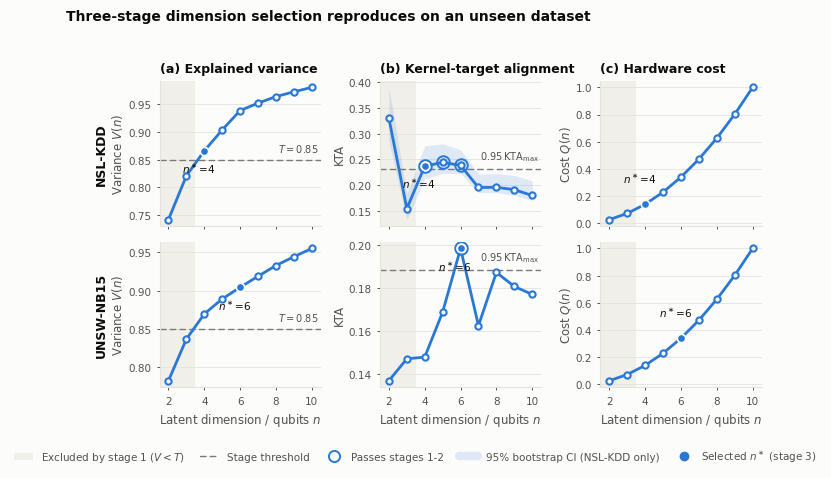

In [6]:
figs.figure5()

## 4. Learning curve NSL-KDD, và crossover

Hai chế độ lấy mẫu, mỗi cái trả lời một câu khác nhau:

| Chế độ | Tỉ lệ lớp hiếm | Câu hỏi |
|---|---|---|
| `natural` | 0.83% — đúng prior thật | Điều gì xảy ra khi triển khai thật? |
| `matched` | 10% — đúng thành phần của `train_run{i}` | Bản đã nộp đo trên phân phối nào? |

> 🔴 **Phát hiện chưa từng ghi trong bản đã nộp**: `train_run{i}` giàu lớp hiếm **gấp 12 lần**
> tỉ lệ tự nhiên (10% so với 0.83%). Đây không phải lỗi, nhưng phải công bố — vì chính nó
> quyết định crossover có xuất hiện hay không.

In [7]:
nat = pd.read_csv(NSL / "c4_per_run_natural_refit_per_N.csv")
nat = nat[(nat.arm == "tuned_per_N") & (nat.test_split == "full_kddtest_plus")]
curve = nat.pivot_table(index="n_train", columns="model", values="f1_macro")
order = ["QSVM_ZZ", "QSVM_Z", "SVM_Linear", "SVM_Poly2", "SVM_RBF",
         "RandomForest", "XGBoost"]
print("macro-F1 trung binh tren 10 run, tap test KDDTest+ day du (che do natural)")
display(curve[order].round(4))

macro-F1 trung binh tren 10 run, tap test KDDTest+ day du (che do natural)


model,QSVM_ZZ,QSVM_Z,SVM_Linear,SVM_Poly2,SVM_RBF,RandomForest,XGBoost
n_train,,,,,,,
100,0.6989,0.7613,0.7261,0.6890,0.7296,0.7695,0.7802
200,0.7283,0.7473,0.7463,0.7292,0.7566,0.7909,0.7924
500,0.7587,0.7717,0.7389,0.7348,0.7880,0.7880,0.7881
1000,0.7717,0.7666,0.7406,0.7424,0.7745,0.7913,0.8007
2000,0.7781,0.7615,0.7373,0.7141,0.7919,0.7839,0.7910
5000,0.7820,0.7596,0.7338,0.7116,0.7794,0.7737,0.7720
10000,0.7855,0.7787,0.7335,0.7114,0.7740,0.7728,0.7706


  -> paper\paper1\figs_revision/fig9_learning_curve_nslkdd.pdf  (+ .png)


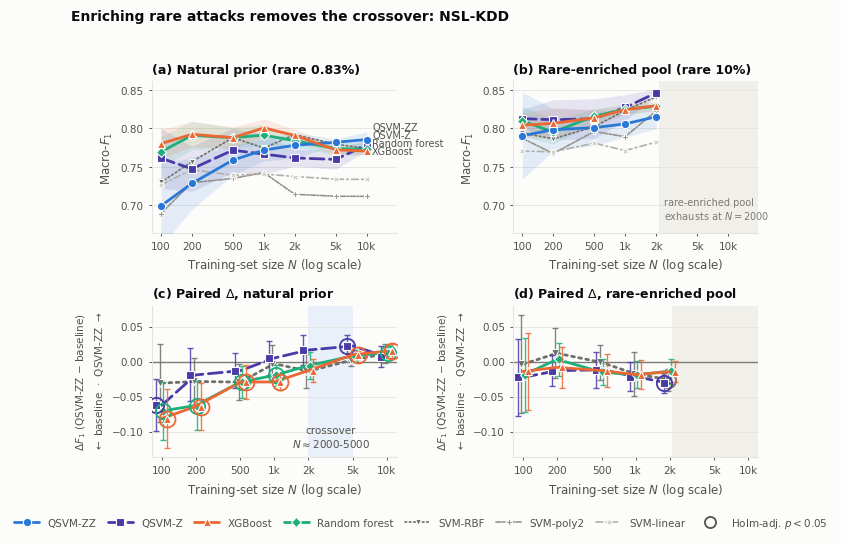

In [8]:
figs.figure9()

### 4.1 Crossover có phải chỉ là tạo tác của việc tune lại không?

Phản biện hiển nhiên nhất: *"crossover chỉ xuất hiện vì các anh tune lại siêu tham số ở mỗi
$N$"*. Trả lời được bằng cách so hai arm:

- `tuned_per_N` — tune lại tại từng $N$ (arm chính)
- `frozen_c2` — đóng băng siêu tham số ở giá trị C2, **không** tune lại

Nếu crossover là tạo tác thì đóng băng phải làm nó biến mất.

In [9]:
st = pd.read_csv(NSL / "c4_pairwise_statistics_natural_all_arms.csv")
st = st[st.test_split == "full_test"]
tab = st[st.baseline.isin(["XGBoost", "RandomForest", "SVM_RBF"])].pivot_table(
    index="n_train", columns=["baseline", "arm"], values="mean_delta")
print("mean_delta = QSVM_ZZ - baseline  (duong = QSVM-ZZ tot hon)")
display(tab.round(4))

print("\nDoi dau o dau:")
for (b, arm), s in tab.items():
    s = s.dropna()
    flips = [f"{s.index[i]} -> {s.index[i+1]}" for i in range(len(s) - 1)
             if (s.values[i] < 0) != (s.values[i + 1] < 0)]
    print(f"  {b:13s} {arm:12s}: {flips or 'khong doi dau'}")

mean_delta = QSVM_ZZ - baseline  (duong = QSVM-ZZ tot hon)


baseline RandomForest               SVM_RBF               XGBoost            
arm         frozen_c2 tuned_per_N frozen_c2 tuned_per_N frozen_c2 tuned_per_N
n_train                                                                      
100           -0.0242     -0.0705   -0.0145     -0.0307   -0.0393     -0.0812
200           -0.0196     -0.0627   -0.0073     -0.0284   -0.0236     -0.0641
500           -0.0115     -0.0293   -0.0118     -0.0292   -0.0213     -0.0293
1000          -0.0171     -0.0196   -0.0021     -0.0028   -0.0309     -0.0289
2000          -0.0013     -0.0059   -0.0055     -0.0138   -0.0134     -0.0129
5000           0.0103      0.0082    0.0008      0.0026    0.0114      0.0100
10000          0.0144      0.0127    0.0092      0.0115    0.0169      0.0149


Doi dau o dau:
  RandomForest  frozen_c2   : ['2000 -> 5000']
  RandomForest  tuned_per_N : ['2000 -> 5000']
  SVM_RBF       frozen_c2   : ['2000 -> 5000']
  SVM_RBF       tuned_per_N : ['2000 -> 5000']
  XGBoost       frozen_c2   : ['2000 -> 5000']
  XGBoost       tuned_per_N : ['2000 -> 5000']


**6/6 tổ hợp đổi dấu tại đúng `2000 → 5000`.** Đóng băng siêu tham số thì crossover vẫn nằm
nguyên chỗ cũ → nó **không phải** tạo tác của việc tune lại.

Còn ở chế độ `matched` (lớp hiếm 10%) thì crossover **không xuất hiện** ở cả hai arm — nghĩa
là chính việc làm giàu lớp hiếm mới là thứ xoá crossover.

In [10]:
mt = pd.read_csv(NSL / "c4_pairwise_statistics_matched_all_arms.csv")
mt = mt[mt.test_split == "full_test"]
mtab = mt[mt.baseline.isin(["XGBoost", "RandomForest"])].pivot_table(
    index="n_train", columns=["baseline", "arm"], values="mean_delta")
print("che do matched (lop hiem 10%) -- mean_delta QSVM_ZZ - baseline")
display(mtab.round(4))
print("Moi o deu am o moi N: khong co crossover.")

che do matched (lop hiem 10%) -- mean_delta QSVM_ZZ - baseline


baseline RandomForest               XGBoost            
arm         frozen_c2 tuned_per_N frozen_c2 tuned_per_N
n_train                                                
100           -0.0393     -0.0194   -0.0279     -0.0139
200           -0.0063      0.0032   -0.0169     -0.0082
500           -0.0102     -0.0150   -0.0090     -0.0128
1000          -0.0178     -0.0190   -0.0170     -0.0185
2000          -0.0108     -0.0136   -0.0181     -0.0144

Moi o deu am o moi N: khong co crossover.


### 4.2 Ý nghĩa thống kê

Ghép cặp theo run, Wilcoxon signed-rank, hiệu chỉnh Holm **trong từng family baseline**
(`entanglement` = {QSVM-Z}, `classical_kernel` = {linear, poly2, RBF},
`strong_tabular` = {RF, XGBoost}) — cùng quy ước với C3.

In [11]:
main = st[st.arm == "tuned_per_N"]
piv = main.pivot_table(index="n_train", columns="baseline", values="verdict",
                       aggfunc="first")
display(piv[["QSVM_Z", "SVM_Linear", "SVM_Poly2", "SVM_RBF", "RandomForest", "XGBoost"]])

cols = ["n_train", "baseline", "mean_delta", "ci_low", "ci_high", "holm_p",
        "effect_size_dz", "verdict"]
print("\nChi tiet vs ba baseline manh:")
display(main[main.baseline.isin(["XGBoost", "RandomForest", "SVM_RBF"])][cols]
        .sort_values(["baseline", "n_train"])
        .style.format({c: "{:.4f}" for c in cols[2:-1]}).hide(axis="index"))

baseline,QSVM_Z,SVM_Linear,SVM_Poly2,SVM_RBF,RandomForest,XGBoost
n_train,,,,,,
100,classical-favorable,inconclusive,inconclusive,inconclusive,classical-favorable,classical-favorable
200,inconclusive,inconclusive,inconclusive,inconclusive,classical-favorable,classical-favorable
500,inconclusive,inconclusive,inconclusive,inconclusive,classical-favorable,classical-favorable
1000,inconclusive,QSVM-favorable,inconclusive,inconclusive,classical-favorable,classical-favorable
2000,inconclusive,QSVM-favorable,QSVM-favorable,inconclusive,inconclusive,inconclusive
5000,QSVM-favorable,QSVM-favorable,QSVM-favorable,inconclusive,inconclusive,QSVM-favorable
10000,inconclusive,QSVM-favorable,QSVM-favorable,inconclusive,QSVM-favorable,QSVM-favorable



Chi tiet vs ba baseline manh:


n_train,baseline,mean_delta,ci_low,ci_high,holm_p,effect_size_dz,verdict
100,RandomForest,-0.0705,-0.1124,-0.0287,0.0039,-1.2066,classical-favorable
200,RandomForest,-0.0627,-0.0983,-0.0271,0.0039,-1.2595,classical-favorable
500,RandomForest,-0.0293,-0.0520,-0.0065,0.0273,-0.9215,classical-favorable
1000,RandomForest,-0.0196,-0.0350,-0.0043,0.0273,-0.9149,classical-favorable
2000,RandomForest,-0.0059,-0.0254,0.0137,0.2754,-0.2141,inconclusive
5000,RandomForest,0.0082,0.0004,0.0160,0.0645,0.7563,inconclusive
10000,RandomForest,0.0127,0.0047,0.0208,0.0078,1.1273,QSVM-favorable
100,SVM_RBF,-0.0307,-0.0866,0.0252,0.5508,-0.3925,inconclusive
200,SVM_RBF,-0.0284,-0.0616,0.0049,0.1113,-0.6107,inconclusive
500,SVM_RBF,-0.0292,-0.0551,-0.0034,0.1113,-0.8081,inconclusive


> ⚠️ **Caveat phải giữ trong bài.** Trên NSL-KDD, QSVM-ZZ **chưa từng** thắng SVM-RBF có ý
> nghĩa ở bất kỳ $N$ nào (tại $N=10^4$: $+0.0115$, Holm $p = 0.131$). SVM-RBF mới là baseline
> cổ điển mạnh nhất ở $N$ lớn ($0.7740$, hơn XGBoost $0.7706$) — nên nó phải có mặt trong
> mọi hình, không được lặng lẽ bỏ ra.

## 5. Lớp tấn công hiếm (U2R + R2L)

> 🔴 **Hai lỗi của bản đã nộp, đã kiểm chứng:**
>
> 1. Khẳng định *"+6.7 điểm so với SVM-RBF trên tập con rare"* — **không có metric rare nào
>    tồn tại** ở bất kỳ đâu trong code cũ. Không tái tạo được.
> 2. C5/C6 dùng $|\text{margin}|$. Trên lớp hiếm của NSL-KDD, **margin có dấu là âm với mọi
>    model** — nên $|\text{margin}|$ đang đo *độ tự tin khi trả lời sai*, chứ không đo đúng/sai.
>    Bản revision dùng margin có dấu.

In [12]:
rare = pd.read_csv(NSL / "c4_rare_attack_natural.csv")
r = rare[rare.n_train == rare.n_train.max()]
print(f"NSL-KDD, N = {int(rare.n_train.max())}, che do natural")
display(r[["model", "f1_rare", "recall_rare", "margin_signed_mean",
           "margin_abs_mean"]].round(4).reset_index(drop=True))
print("margin_signed_mean AM voi moi model -> ca 7 deu doan sai phan lon mau hiem;")
print("|margin| lon chi nghia la 'sai mot cach tu tin'.")

NSL-KDD, N = 10000, che do natural


,model,f1_rare,recall_rare,margin_signed_mean,margin_abs_mean
0,QSVM_ZZ,0.5069,0.3400,-0.5050,1.2781
1,QSVM_Z,0.4212,0.2686,-0.4855,0.8772
2,SVM_Linear,0.0886,0.0464,-0.9779,1.0231
3,SVM_Poly2,0.1095,0.0579,-0.6393,0.9538
4,SVM_RBF,0.5846,0.4170,-0.3482,0.8377
5,RandomForest,0.3306,0.1982,-0.2491,0.3657
6,XGBoost,0.3342,0.2009,-0.2778,0.4124


margin_signed_mean AM voi moi model -> ca 7 deu doan sai phan lon mau hiem;
|margin| lon chi nghia la 'sai mot cach tu tin'.


In [13]:
piv = rare.pivot_table(index="n_train", columns="model", values="recall_rare")
print("recall tren lop hiem theo N -- co che dang sau crossover")
display(piv[order].round(4))
print("Ensemble cay dat dinh quanh N=1000 roi giam; QSVM-ZZ tang don dieu.")

recall tren lop hiem theo N -- co che dang sau crossover


model,QSVM_ZZ,QSVM_Z,SVM_Linear,SVM_Poly2,SVM_RBF,RandomForest,XGBoost
n_train,,,,,,,
100,0.2189,0.2851,0.0588,0.0954,0.1357,0.1529,0.1674
200,0.2225,0.2691,0.0478,0.1634,0.1913,0.2220,0.2546
500,0.2349,0.2848,0.0502,0.1980,0.3165,0.2002,0.2059
1000,0.3264,0.2633,0.0468,0.1957,0.2547,0.2468,0.2783
2000,0.3275,0.2735,0.0464,0.1082,0.4401,0.2360,0.2544
5000,0.3421,0.2648,0.0464,0.0566,0.4383,0.2058,0.2119
10000,0.3400,0.2686,0.0464,0.0579,0.4170,0.1982,0.2009


Ensemble cay dat dinh quanh N=1000 roi giam; QSVM-ZZ tang don dieu.


## 6. Chuyển giao sang UNSW-NB15

Câu hỏi: những kết luận nào **chuyển giao được** sang một bộ dữ liệu khác, và cái nào không.

  -> paper\paper1\figs_revision/fig11_unsw_transfer.pdf  (+ .png)


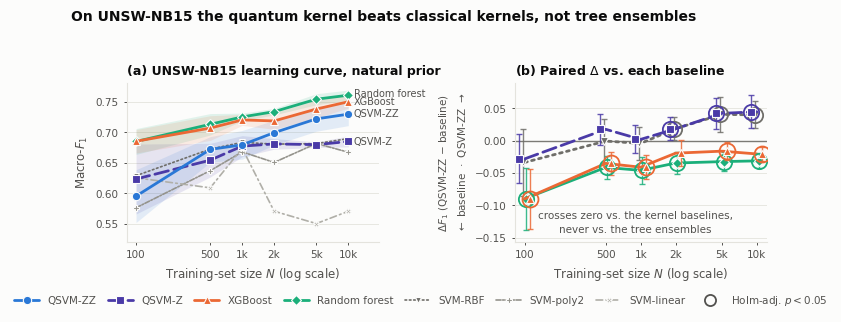

In [14]:
figs.figure11()

In [15]:
su = pd.read_csv(UNSW / "c4_pairwise_statistics_natural.csv")
su = su[(su.arm == "tuned_per_N") & (su.test_split == "full_test")]
display(su.pivot_table(index="n_train", columns="baseline", values="verdict",
                       aggfunc="first"))

baseline,QSVM_Z,RandomForest,SVM_Linear,SVM_Poly2,SVM_RBF,XGBoost
n_train,,,,,,
100,inconclusive,classical-favorable,inconclusive,inconclusive,inconclusive,classical-favorable
500,inconclusive,classical-favorable,inconclusive,inconclusive,inconclusive,classical-favorable
1000,inconclusive,classical-favorable,inconclusive,inconclusive,inconclusive,classical-favorable
2000,QSVM-favorable,classical-favorable,QSVM-favorable,QSVM-favorable,QSVM-favorable,inconclusive
5000,QSVM-favorable,classical-favorable,QSVM-favorable,QSVM-favorable,QSVM-favorable,classical-favorable
10000,QSVM-favorable,classical-favorable,QSVM-favorable,QSVM-favorable,QSVM-favorable,classical-favorable


**Chuyển giao được:**

- Luật chọn số chiều C1 — cùng thủ tục, ra $n^\ast = 6$ (10/10 subset độc lập)
- Ablation entanglement — ZZ hơn Z $+0.045$, $p = 0.002$ tại $N = 10^4$, **gấp đôi** mức trên NSL-KDD
- QSVM-ZZ thắng SVM-RBF có ý nghĩa từ $N \ge 2000$ ($+0.040$, Holm $p = 0.006$)

**Không chuyển giao được:**

- Crossover so với ensemble cây — trên UNSW cổ điển thắng ở **mọi** $N$
- Lợi thế trên lớp hiếm — lớp hiếm của UNSW dễ hơn nhiều (recall 0.94–0.99)

> ⚠️ **Đừng trích số của arm `tuned_once` ở $N$ nhỏ.** Nó cho $\Delta = +0.2223$ so với
> SVM-RBF tại $N = 100$, nhìn như quantum thắng đậm. Thực ra siêu tham số tune một lần lệch
> hẳn khi xuống $N$ nhỏ và **phạt SVM-RBF chứ không phạt QSVM** — xem ô dưới.

In [16]:
d = pd.read_csv(UNSW / "c4_per_run_unsw_natural_refit_per_N.csv")
d = d[(d.test_split == "full_test") & (d.n_train == 100)]
p = d.pivot_table(index="model", columns="arm", values=["f1_macro", "recall_macro"])
print("UNSW, N = 100 -- tac dong cua arm len tung model")
display(p.round(4).loc[["QSVM_ZZ", "SVM_RBF", "XGBoost"]])
print("SVM-RBF mat 0.265 F1 khi doi sang tuned_once (recall_macro 0.504 = gan suy bien);")
print("QSVM-ZZ chi mat 0.010. Arm nay khong phai phep so sanh cong bang o N nho.")

UNSW, N = 100 -- tac dong cua arm len tung model


f1_macro             recall_macro            
arm     tuned_once tuned_per_N   tuned_once tuned_per_N
model                                                  
QSVM_ZZ     0.5858      0.5953       0.6170      0.6237
SVM_RBF     0.3635      0.6289       0.5041      0.6518
XGBoost     0.6864      0.6855       0.6892      0.6886

SVM-RBF mat 0.265 F1 khi doi sang tuned_once (recall_macro 0.504 = gan suy bien);
QSVM-ZZ chi mat 0.010. Arm nay khong phai phep so sanh cong bang o N nho.


## 7. Bản đồ chế độ — tổng hợp C2 + C3 + C4

110 so sánh có kiểm định, gộp từ cả ba đóng góp, cùng một quy ước verdict.

  -> paper\paper1\figs_revision/fig10_regime_map.pdf  (+ .png)


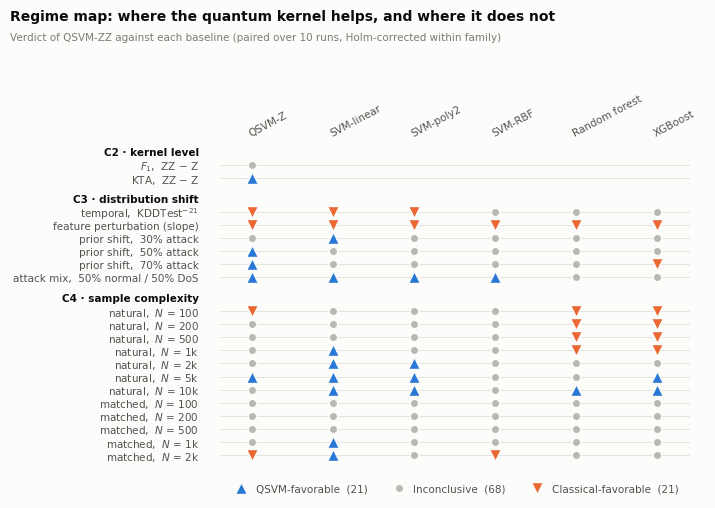

In [17]:
figs.figure10()

In [18]:
rm = pd.read_csv(ROOT / "results/nslkdd/regime_map_rows.csv")
display(rm.pivot_table(index="contribution", columns="verdict", values="metric",
                       aggfunc="count", fill_value=0))
print(f"tong: {len(rm)} so sanh")

verdict,QSVM-favorable,classical-favorable,inconclusive
contribution,,,
C2,1,0,1
C3,7,10,19
C4,13,11,48


tong: 110 so sanh


## 8. Hai bảng trả lời trực tiếp câu hỏi reviewer

### 8.1 Vì sao Table IV và Table VI của bản đã nộp lệch nhau

Tách được thành hai nguồn tách bạch.

In [19]:
t = pd.read_csv(NSL / "c4_table_iv_vs_vi.csv")
display(t.round(4))
zz = t.set_index(["repr_mode", "test_split"])["QSVM_ZZ"]
print(f"do tap test  : {zz[('frozen_c1', 'full_kddtest_plus')] - zz[('frozen_c1', 'fixed_300')]:+.4f}"
      "   (300 mau co dinh -> KDDTest+ day du)")
print(f"do bieu dien : {zz[('refit_per_N', 'fixed_300')] - zz[('frozen_c1', 'fixed_300')]:+.4f}"
      "   (dong bang C1 -> refit theo tung N)")

,repr_mode,test_split,QSVM_ZZ,QSVM_Z,SVM_RBF,RandomForest,XGBoost
0,frozen_c1,fixed_300,0.8469,0.8355,0.8362,0.8446,0.8503
1,frozen_c1,full_kddtest_plus,0.7959,0.7721,0.7977,0.8009,0.8043
2,refit_per_N,fixed_300,0.8526,0.8715,0.8645,0.8673,0.8666
3,refit_per_N,full_kddtest_plus,0.8072,0.8250,0.8273,0.8250,0.8242


do tap test  : -0.0510   (300 mau co dinh -> KDDTest+ day du)
do bieu dien : +0.0057   (dong bang C1 -> refit theo tung N)


### 8.2 Vì sao bài này báo 0.80 trong khi tài liệu khác báo 0.99

Không phải model kém hơn — mà là **giao thức đánh giá khác nhau**. Cùng model, cùng feature,
chỉ đổi cách chia dữ liệu.

In [20]:
lit = pd.read_csv(NSL / "c4_protocol_vs_literature.csv")
display(lit.pivot_table(index="setup", columns="model", values="f1_macro").round(4))
print("A: train day du, do tren KDDTest+      -> giao thuc cua bai nay")
print("B: chia ngau nhien tu KDDTrain+        -> ~0.999, con so hay gap trong tai lieu")
print("C: PCA 4 chieu, do tren KDDTest+       -> co lap tac dong cua giam chieu")
print("\nKDDTest+ chua nhung ho tan cong KHONG co trong KDDTrain+; chia ngau nhien")
print("thi xoa mat dieu do, nen so dep len nhung khong con do duoc kha nang tong quat hoa.")

model,RandomForest,XGBoost
setup,,
A_full122_fulltrain_KDDTestPlus,0.7765,0.8041
B_full122_randomsplit_KDDTrain,0.9978,0.9993
C_pca4_fulltrain_KDDTestPlus,0.7560,0.7655


A: train day du, do tren KDDTest+      -> giao thuc cua bai nay
B: chia ngau nhien tu KDDTrain+        -> ~0.999, con so hay gap trong tai lieu
C: PCA 4 chieu, do tren KDDTest+       -> co lap tac dong cua giam chieu

KDDTest+ chua nhung ho tan cong KHONG co trong KDDTrain+; chia ngau nhien
thi xoa mat dieu do, nen so dep len nhung khong con do duoc kha nang tong quat hoa.


## 9. Những chỗ phải giữ nguyên khi viết bài

| # | Nội dung | Mức |
|---|---|---|
| 1 | `train_run{i}` giàu lớp hiếm gấp 12 lần tỉ lệ tự nhiên — phải công bố | 🔴 |
| 2 | Khẳng định `+6.7 / d=+0.68` của bản cũ không tái tạo được — phải bỏ | 🔴 |
| 3 | $\|$margin$\|$ đo sai thứ cần đo trên lớp hiếm — dùng margin có dấu | 🔴 |
| 4 | NSL-KDD: QSVM-ZZ **chưa từng** thắng SVM-RBF có ý nghĩa | 🔴 |
| 5 | Arm `tuned_once` (UNSW) phạt SVM-RBF ở $N$ nhỏ — vào mục hạn chế | 🔴 |
| 6 | XGBoost dao động ±0.001 giữa các máy ngay cả khi `n_jobs=1` | 🟡 |
| 7 | Crossover không phải tạo tác của tune lại (6/6 tổ hợp) — kết quả mới, nên đưa vào | 🟢 |
| 8 | KDDTrain+ và KDDTest+ trùng 610 dòng — thuộc tính dataset, phải nói | 🟡 |

Nhật ký đầy đủ: `docs/revision/02_PROGRESS.md` · Báo cáo soát lỗi: `docs/revision/06_AUDIT_C4.md`